In [ ]:
#pip install statsmodels pandas numpy mtplotlib seaborn

In [2]:
import statsmodels.formula.api as smf
import statsmodels.api as sm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('data/house_prices.csv')

In [22]:
df.dtypes

price              float64
bedrooms             int64
bathrooms          float64
sqft_living          int64
sqft_lot             int64
floors             float64
waterfront           int64
view                 int64
condition            int64
grade                int64
yr_built             int64
zipcode              int64
lat                float64
long               float64
renovated            int64
basement             int64
log_price          float64
log_sqft_living    float64
lat_c              float64
long_c             float64
age                  int64
dtype: object

In [4]:
df['log_price'] = np.log(df['price'])
df['log_sqft_living'] = np.log(df['sqft_living'])
df['lat_c'] = df['lat'] - df['lat'].mean()
df['long_c'] = df['long'] - df['long'].mean()
df['age'] = 2015 - df['yr_built']

In [5]:
model = smf.ols('log_price ~ bathrooms + log_sqft_living + C(zipcode) + floors + waterfront + view + condition + grade + age + renovated + basement', data = df) 
model = model.fit(cov_type='HC3')
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              log_price   R-squared:                       0.873
Model:                            OLS   Adj. R-squared:                  0.873
Method:                 Least Squares   F-statistic:                     1606.
Date:                Fri, 15 May 2026   Prob (F-statistic):               0.00
Time:                        20:54:28   Log-Likelihood:                 5517.9
No. Observations:               21613   AIC:                        -1.088e+04
Df Residuals:                   21533   BIC:                        -1.024e+04
Df Model:                          79                                         
Covariance Type:                  HC3                                         
=======================================================================================
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               7.8333      0.043    181.770      0.000       7.749       7.918
C(zipcode)[T.98002]    -0.0346      0.015     -2.336      0.019      -0.064      -0.006
C(zipcode)[T.98003]     0.0039      0.013      0.289      0.773      -0.022       0.030
C(zipcode)[T.98004]     1.1282      0.016     72.715      0.000       1.098       1.159
C(zipcode)[T.98005]     0.7383      0.016     45.723      0.000       0.707       0.770
C(zipcode)[T.98006]     0.6454      0.013     48.644      0.000       0.619       0.671
C(zipcode)[T.98007]     0.6310      0.015     42.296      0.000       0.602       0.660
C(zipcode)[T.98008]     0.6277      0.013     46.866      0.000       0.601       0.654
C(zipcode)[T.98010]     0.2971      0.031      9.632      0.000       0.237       0.358
C(zipcode)[T.98011]     0.4526      0.013     33.660      0.000       0.426       0.479
C(zipcode)[T.98014]     0.3755      0.027     14.096      0.000       0.323       0.428
C(zipcode)[T.98019]     0.3598      0.016     22.981      0.000       0.329       0.390
C(zipcode)[T.98022]     0.0784      0.017      4.659      0.000       0.045       0.111
C(zipcode)[T.98023]    -0.0343      0.012     -2.830      0.005      -0.058      -0.011
C(zipcode)[T.98024]     0.5139      0.026     19.466      0.000       0.462       0.566
C(zipcode)[T.98027]     0.5388      0.013     41.197      0.000       0.513       0.564
C(zipcode)[T.98028]     0.4157      0.013     30.967      0.000       0.389       0.442
C(zipcode)[T.98029]     0.5886      0.012     50.830      0.000       0.566       0.611
C(zipcode)[T.98030]     0.0508      0.013      3.784      0.000       0.024       0.077
C(zipcode)[T.98031]     0.0714      0.013      5.463      0.000       0.046       0.097
C(zipcode)[T.98032]    -0.0374      0.020     -1.909      0.056      -0.076       0.001
C(zipcode)[T.98033]     0.7807      0.015     53.598      0.000       0.752       0.809
C(zipcode)[T.98034]     0.5318      0.012     44.054      0.000       0.508       0.555
C(zipcode)[T.98038]     0.1884      0.012     15.766      0.000       0.165       0.212
C(zipcode)[T.98039]     1.3176      0.025     52.663      0.000       1.269       1.367
C(zipcode)[T.98040]     0.8804      0.015     59.699      0.000       0.852       0.909
C(zipcode)[T.98042]     0.0747      0.012      6.122      0.000       0.051       0.099
C(zipcode)[T.98045]     0.3569      0.016     22.411      0.000       0.326       0.388
C(zipcode)[T.98052]     0.6364      0.012     55.307      0.000       0.614       0.659
C(zipcode)[T.98053]     0.6252      0.012     50.795      0.000       0.601       0.649
C(zipcode)[T.98055]     0.1367      0.016      8.511      0.000       0.105       0.168
C(zipcode)[T.98056]     0.3176      0.014     22.974      0.000       0.290       0.345
C(z

<Axes: >

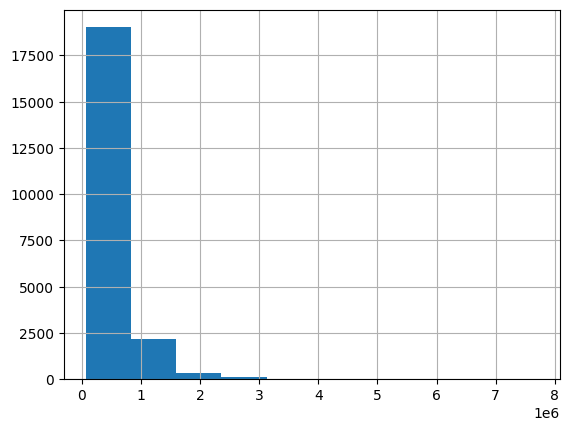

In [6]:
df.price.hist()

<Axes: >

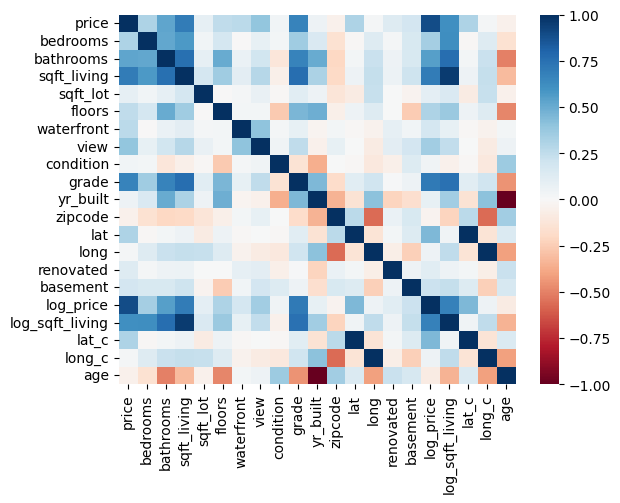

In [7]:
cor_table = df.select_dtypes(exclude = "object").corr()
sns.heatmap(cor_table, vmin = -1, vmax = 1, center =0,cmap = "RdBu")

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

numeric_features = ['log_sqft_living', 'bathrooms', 'bedrooms', 'grade', 
                    'condition', 'view', 'waterfront', 'age', 
                    'renovated', 'basement', 'floors']

X = add_constant(df[numeric_features])
vif = pd.DataFrame({
    'feature': X.columns[1:],
    'VIF': [variance_inflation_factor(X.values, i) for i in range(1, X.shape[1])]
}).sort_values('VIF', ascending=False)
print(vif)

            feature       VIF
0   log_sqft_living  4.234046
1         bathrooms  3.282482
3             grade  2.761446
7               age  1.985856
2          bedrooms  1.769971
10           floors  1.742702
5              view  1.346575
9          basement  1.333678
4         condition  1.218446
6        waterfront  1.201075
8         renovated  1.142529


In [9]:
import statsmodels.stats.api as sms
model_resid = model.resid
model_fittedvalues = model.fittedvalues
model_exog = model.model.exog

In [ ]:
from statsmodels.compat import lzip
names = ['Lagrange multiplier statistic', 'p-value',
        'f-value', 'f p-value']
test = sms.het_breuschpagan(model_resid, model_exog)
lzip(names, test)

#W tym wypadku heteroskedastyczność nie powinna stanowić problemu, bo w modelu zastosowano odporne błędy standardowe HC3

[('Lagrange multiplier statistic', np.float64(1357.4353692778482)),
 ('p-value', np.float64(5.879598290602231e-232)),
 ('f-value', np.float64(18.266370247763664)),
 ('f p-value', np.float64(1.5846770285502183e-240))]

<Axes: xlabel='None', ylabel='None'>

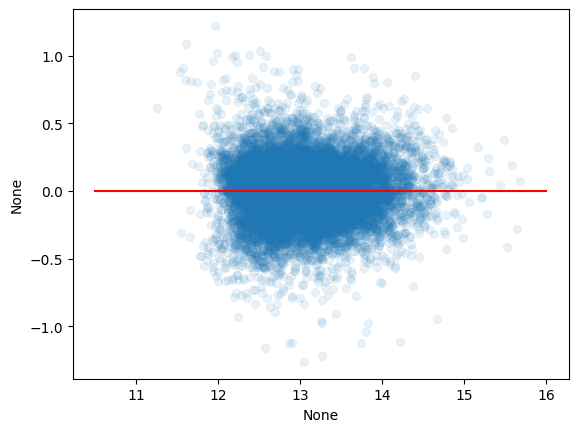

In [18]:
sns.scatterplot(x = model_fittedvalues, y = model_resid, alpha=0.1, edgecolor=None)
sns.lineplot(x = [10.5, 16], y = [0, 0], color = 'red')